In [139]:
import pandas as pd 
import numpy as np

In [140]:
df=pd.read_csv('startup_funding.csv')
df

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN
...,...,...,...,...,...,...,...,...,...,...
3039,3040,29/01/2015,Printvenue,NaN,NaN,NaN,Asia Pacific Internet Group,Private Equity,"45,00,000",NaN
3040,3041,29/01/2015,Graphene,NaN,NaN,NaN,KARSEMVEN Fund,Private Equity,"8,25,000",Govt backed VC Fund
3041,3042,30/01/2015,Mad Street Den,NaN,NaN,NaN,"Exfinity Fund, GrowX Ventures.",Private Equity,"15,00,000",NaN
3042,3043,30/01/2015,Simplotel,NaN,NaN,NaN,MakeMyTrip,Private Equity,NaN,"Strategic Funding, Minority stake"


In [141]:
df.drop(columns=['Remarks'],inplace=True)

In [142]:
df.set_index('Sr No',inplace=True)

In [143]:

df.rename(columns={
    'Date dd/mm/yyyy':'date',
    'Startup Name':'startup',
    'Industry Vertical':'vertical',
    'SubVertical':'subvertical',
    'City  Location':'city',
    'Investors Name':'investors',
    'InvestmentnType':'round',
    'Amount in USD':'amount'

},inplace=True)

In [144]:
df['amount']=df['amount'].fillna('0')

In [145]:
df['amount']=df['amount'].str.replace(',','')
df['amount']=df['amount'].str.replace('undisclosed','0')
df['amount']=df['amount'].str.replace('Undisclosed','0')
df['amount']=df['amount'].str.replace('unknown','0')


In [146]:
df=df[df['amount'].str.isdigit()]

In [147]:
df['amount']=df['amount'].astype('float')

In [148]:
def to_inr(dollor):
     inr=dollor*95
     return inr/10000000

In [149]:
df['amount']=df['amount'].apply(to_inr)

In [150]:
df['date']=df['date'].str.replace('05/072018','05/07/2018')

In [151]:
df['date']=pd.to_datetime(df['date'],format='%d/%m/%Y',errors='coerce')

In [152]:
df.info()

<class 'pandas.DataFrame'>
Index: 3029 entries, 1 to 3044
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         3023 non-null   datetime64[us]
 1   startup      3029 non-null   str           
 2   vertical     2858 non-null   str           
 3   subvertical  2104 non-null   str           
 4   city         2849 non-null   str           
 5   investors    3005 non-null   str           
 6   round        3027 non-null   str           
 7   amount       3029 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(6)
memory usage: 513.1 KB


In [153]:
df=df.dropna(subset=['date','startup','vertical','city','investors','round','amount'])

In [154]:
df.info()

<class 'pandas.DataFrame'>
Index: 2819 entries, 1 to 2873
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         2819 non-null   datetime64[us]
 1   startup      2819 non-null   str           
 2   vertical     2819 non-null   str           
 3   subvertical  2078 non-null   str           
 4   city         2819 non-null   str           
 5   investors    2819 non-null   str           
 6   round        2819 non-null   str           
 7   amount       2819 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(6)
memory usage: 485.7 KB


In [155]:
df.to_csv('startup_cleaned.csv',index=False)

In [156]:
sorted(set(df['investors'].str.split(',').sum()))

['',
 ' & Others',
 ' 100 Co-founders Lab and others.',
 ' 122 West Ventures',
 ' 1Crowd',
 ' 3ONE4 Capital Advisors',
 ' 3one4 Capital',
 ' 3one4 Capital Advisors LLP',
 ' 500 Start-Ups',
 ' 500 Startups',
 ' 500 Startups & Other HNIs',
 ' 50K Ventures & others',
 ' 91SpringBoard',
 ' 91springboard',
 ' ABB Technology Ventures',
 ' ABCOM Investments',
 ' AECAL',
 ' AET Fund',
 ' AL Nour International Holdings and Mark V Investments',
 ' ASP Consulting',
 ' AVN Business Solutions',
 ' Aarin Capital',
 ' Aarin Capital & Others',
 ' Aaruha Technology Fund',
 ' Abaran Deep',
 ' Abhai S. Rao',
 ' Abhay Singhal',
 ' Abhijit Bhandari',
 ' Abhinav Patodia',
 ' Abhinav Sinha',
 ' Abhishek Acharya',
 ' Abhishek Goyal',
 ' Abhishek Gupta',
 ' Abhishek Jain',
 ' Abhishekh Goyal',
 ' Abstract Ventures',
 ' Abu Farhan Azmi',
 ' Accel',
 ' Accel India',
 ' Accel Partner',
 ' Accel Partners',
 ' Accel Partners & Others',
 ' Accel Partners & Raghunandan Gangappa',
 ' Accel Partners & existing investor

In [157]:
df[df['investors'].str.contains(' IDG Ventures')].head()[['date','startup','vertical','city','round','amount']]

,date,startup,vertical,city,round,amount
Sr No,,,,,,
102,2019-04-13,Tripoto,Social Media,New Delhi,Series B,34.118063
259,2018-05-02,Bizongo,Consumer Internet,Mumbai,Private Equity,209.000000
310,2018-04-26,POPxo,Technology,Delhi,Private Equity,52.250000
505,2017-11-21,Heckyl,Technology,Mumbai,Private Equity,25.650000
528,2017-10-05,Little Black Book,Consumer Internet,New Delhi,Private Equity,9.500000


In [158]:
df[df['investors'].str.contains(' IDG Ventures')].groupby('startup')['amount'].sum().sort_values(ascending=False)

startup
Lenskart                 570.000000
CureFit                  237.500000
Bizongo                  209.000000
Curefit                  142.500000
Xpressbees               118.750000
FirstCry.com              95.000000
POPxo                     81.700000
\\xc2\\xa0CloudCherry     57.000000
Sigtuple                  55.100000
Aasaanjobs                47.500000
RentMojo                  47.500000
PlaySimple                38.000000
Tripoto                   34.118063
Active.ai                 28.500000
Heckyl                    25.650000
Cloudcherry Analytics      9.500000
Little Black Book          9.500000
Name: amount, dtype: float64

<Axes: >

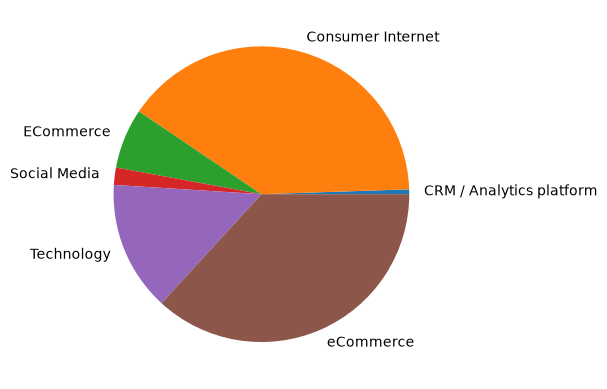

In [159]:
df[df['investors'].str.contains(' IDG Ventures')].groupby('vertical')['amount'].sum().plot(kind='pie')

<Axes: >

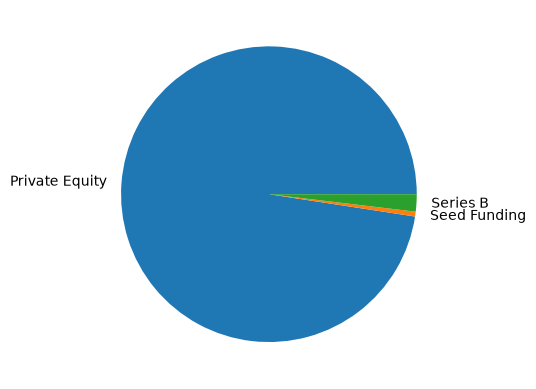

In [160]:
df[df['investors'].str.contains(' IDG Ventures')].groupby('round')['amount'].sum().plot(kind='pie')

<Axes: >

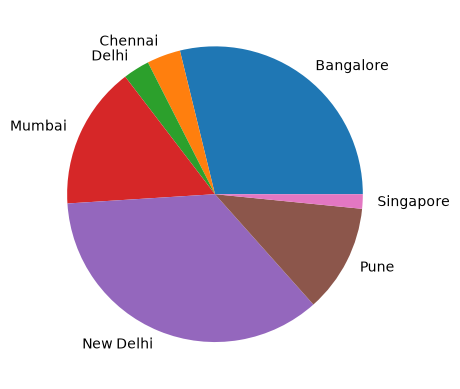

In [161]:
df[df['investors'].str.contains(' IDG Ventures')].groupby('city')['amount'].sum().plot(kind='pie')

In [162]:
df.info()

<class 'pandas.DataFrame'>
Index: 2819 entries, 1 to 2873
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         2819 non-null   datetime64[us]
 1   startup      2819 non-null   str           
 2   vertical     2819 non-null   str           
 3   subvertical  2078 non-null   str           
 4   city         2819 non-null   str           
 5   investors    2819 non-null   str           
 6   round        2819 non-null   str           
 7   amount       2819 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(6)
memory usage: 485.7 KB


In [163]:
df['year']=df['date'].dt.year

<Axes: xlabel='year'>

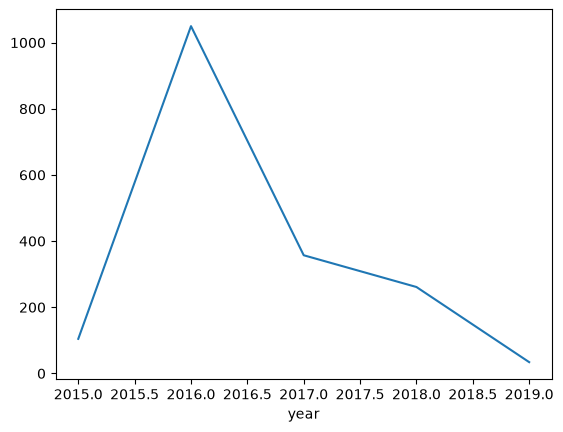

In [164]:
df[df['investors'].str.contains(' IDG Ventures')].groupby('year')['amount'].sum().plot()

In [165]:
df1=pd.read_csv('startup_cleaned.csv')

In [166]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 2819 entries, 0 to 2818
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         2819 non-null   str    
 1   startup      2819 non-null   str    
 2   vertical     2819 non-null   str    
 3   subvertical  2078 non-null   str    
 4   city         2819 non-null   str    
 5   investors    2819 non-null   str    
 6   round        2819 non-null   str    
 7   amount       2819 non-null   float64
dtypes: float64(1), str(7)
memory usage: 489.7 KB


In [167]:
round(df['amount'].sum())

341391

In [168]:
round(df['amount'].max())

37050

In [169]:
df.groupby('startup')['amount'].max().sort_values(ascending=False).head(1).values[0]

np.float64(37050.0)

In [170]:
df.groupby('startup')['amount'].sum().mean()

np.float64(148.62474775032652)

In [171]:
df['startup'].nunique()

2297

In [172]:
df['month']=df['date'].dt.month

In [173]:
df

,date,startup,vertical,subvertical,city,investors,round,amount,year,month
Sr No,,,,,,,,,,
1,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1900.000000,2020,1
2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,76.459743,2020,1
3,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,174.409170,2020,1
4,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,28.500000,2020,1
5,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,17.100000,2020,1
...,...,...,...,...,...,...,...,...,...,...
2869,2015-04-29,Tracxn,Startup Analytics platform,NaN,Bangalore,SAIF Partners,Private Equity,33.250000,2015,4
2870,2015-04-29,Dazo,Mobile Food Ordering app,NaN,Bangalore,"Sumit Jain, Aprameya Radhakrishna, Alok Goel, ...",Seed Funding,0.000000,2015,4
2871,2015-04-29,Tradelab,Financial Markets Software,NaN,Bangalore,Rainmatter,Seed Funding,3.800000,2015,4


In [ ]:
df.groupby(['year','month'])['startup'].count().reset_index()

In [185]:
temp_df=df.groupby(['year','month'])['amount'].sum().reset_index()

In [186]:
temp_df['x_axis']=temp_df['month'].astype('str')+'-'+temp_df['year'].astype('str')

In [187]:
temp_df[['amount','x_axis']]

,amount,x_axis
0,9305.250000,4-2015
1,3041.282500,5-2015
2,4954.193000,6-2015
3,14337.324000,7-2015
4,10106.252000,8-2015
5,13960.440000,9-2015
6,2422.129500,10-2015
7,8521.072500,11-2015
8,2905.603500,12-2015
9,6648.860000,1-2016
